<a href="https://colab.research.google.com/github/cjdevx-ai/Robotics-Technology-Assignments/blob/main/ML_Regression_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Imports & Configuration

In [1]:
import pandas as pd                        # pandas - Python Data Analysis
import numpy as np                         # numpy - Numerical Python
import matplotlib.pyplot as plt            # matplotlib - comprehensive Python library for creating static, animated, and interactive visualizations
import matplotlib.gridspec as gridspec     # GridSpec - lets you create complex, customized subplot layouts
import seaborn as sns                      # Seaborn - Python data visualization library built on top of Matplotlib
import warnings                            # controls how warning messages are displayed during program execution
warnings.filterwarnings('ignore')          # suppress all warning messages during execution

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, BaggingRegressor,
                               GradientBoostingRegressor, AdaBoostRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Colour palette
TEAL   = '#2C7873'; GOLD   = '#F4A261'; ROSE   = '#E76F51'
NAVY   = '#264653'; MINT   = '#52B788'; LAVEND = '#9B72CF'
COLORS = [TEAL, GOLD, ROSE, NAVY, MINT, LAVEND,
          '#E9C46A','#457B9D','#A8DADC','#1D3557','#F77F00']

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## 1. Load Dataset

In [2]:
df = pd.read_csv('Life Expectancy Data.csv')
df.columns = df.columns.str.strip()
TARGET = 'Life expectancy'

print(f"Dataset shape : {df.shape}")
print(f"Target column : '{TARGET}'")
print(f"\nColumn list ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>2}. {col}")

Dataset shape : (2938, 22)
Target column : 'Life expectancy'

Column list (22):
   1. Country
   2. Year
   3. Status
   4. Life expectancy
   5. Adult Mortality
   6. infant deaths
   7. Alcohol
   8. percentage expenditure
   9. Hepatitis B
  10. Measles
  11. BMI
  12. under-five deaths
  13. Polio
  14. Total expenditure
  15. Diphtheria
  16. HIV/AIDS
  17. GDP
  18. Population
  19. thinness  1-19 years
  20. thinness 5-9 years
  21. Income composition of resources
  22. Schooling


In [3]:
df.dtypes

,0
Country,object
Year,int64
Status,object
Life expectancy,float64
Adult Mortality,float64
infant deaths,int64
Alcohol,float64
percentage expenditure,float64
Hepatitis B,float64
Measles,int64


In [4]:
### Check data types
print("Data Types:\n")
print(df.dtypes)

Data Types:

Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
BMI                                float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
HIV/AIDS                           float64
GDP                                float64
Population                         float64
thinness  1-19 years               float64
thinness 5-9 years                 float64
Income composition of resources    float64
Schooling                          float64
dtype: object


## 2. Data Preparation

In [5]:
mv = df.isnull().sum()
mv

,0
Country,0
Year,0
Status,0
Life expectancy,10
Adult Mortality,10
infant deaths,0
Alcohol,194
percentage expenditure,0
Hepatitis B,553
Measles,0


In [6]:
# Missing value report
mv = df.isnull().sum()
print("Missing values per column:")
print(mv[mv > 0].to_string())
print(f"\nTotal missing cells: {mv.sum()}")

Missing values per column:
Life expectancy                     10
Adult Mortality                     10
Alcohol                            194
Hepatitis B                        553
BMI                                 34
Polio                               19
Total expenditure                  226
Diphtheria                          19
GDP                                448
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163

Total missing cells: 2563


In [7]:
# Address Missing Cells:
# Median imputation - replacing missing values (NaN) with the median value of that column
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

mv = df.isnull().sum()
mv

,0
Country,0
Year,0
Status,0
Life expectancy,0
Adult Mortality,0
infant deaths,0
Alcohol,0
percentage expenditure,0
Hepatitis B,0
Measles,0


In [8]:
# Label Encoding - machine learning models only understand numbers
le_enc = LabelEncoder()
df['Status'] = le_enc.fit_transform(df['Status'])  # Developed=1, Developing=0

# Drop Country & Year as features - they identify who the data is about,
# not what causes life expectancy to change
df = df.drop(columns=['Country', 'Year'])

# Address Missing Cells:
# Median imputation - replacing missing values (NaN) with the median value of that column
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Drop rows with null target (safety - to make sure no missing cells)
df = df.dropna(subset=[TARGET])

# IQR outlier removal on target - outliers can distort model training
Q1, Q3 = df[TARGET].quantile(0.25), df[TARGET].quantile(0.75)
IQR = Q3 - Q1
df = df[(df[TARGET] >= Q1 - 1.5*IQR) & (df[TARGET] <= Q3 + 1.5*IQR)]

print(f"✅ Missing values after imputation : {df.isnull().sum().sum()}")
print(f"✅ Shape after outlier removal     : {df.shape}")

✅ Missing values after imputation : 0
✅ Shape after outlier removal     : (2921, 20)


In [9]:
df

,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,1,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,1,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,1,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,1,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,1,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2930,1,46.6,67.0,29,3.88,29.814566,72.0,242,28.2,46,73.0,4.47,73.0,23.7,396.998217,1332999.0,8.2,8.2,0.414,9.6
2931,1,45.4,7.0,28,4.57,34.262169,68.0,212,27.9,45,71.0,5.12,7.0,26.8,414.796232,13124267.0,8.6,8.6,0.408,9.5
2935,1,44.8,73.0,25,4.43,0.000000,73.0,304,26.3,40,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,1,45.3,686.0,25,1.72,0.000000,76.0,529,25.9,39,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [10]:
# Declaration of X-Independent variable & Y-Dependent variable
X = df.drop(columns=[TARGET])
y = df[TARGET]

In [11]:
feature_names = X.columns.tolist()
print(f"Features ({len(feature_names)}): {feature_names}")

Features (19): ['Status', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [12]:
X

,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,1,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,1,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,1,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,1,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,1,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2930,1,67.0,29,3.88,29.814566,72.0,242,28.2,46,73.0,4.47,73.0,23.7,396.998217,1332999.0,8.2,8.2,0.414,9.6
2931,1,7.0,28,4.57,34.262169,68.0,212,27.9,45,71.0,5.12,7.0,26.8,414.796232,13124267.0,8.6,8.6,0.408,9.5
2935,1,73.0,25,4.43,0.000000,73.0,304,26.3,40,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,1,686.0,25,1.72,0.000000,76.0,529,25.9,39,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [13]:
y

,Life expectancy
0,65.0
1,59.9
2,59.9
3,59.5
4,59.2
...,...
2930,46.6
2931,45.4
2935,44.8
2936,45.3


In [14]:
feature_names

['Status',
 'Adult Mortality',
 'infant deaths',
 'Alcohol',
 'percentage expenditure',
 'Hepatitis B',
 'Measles',
 'BMI',
 'under-five deaths',
 'Polio',
 'Total expenditure',
 'Diphtheria',
 'HIV/AIDS',
 'GDP',
 'Population',
 'thinness  1-19 years',
 'thinness 5-9 years',
 'Income composition of resources',
 'Schooling']

In [15]:
X.shape

(2921, 19)

In [16]:
y.shape

(2921,)

In [17]:
X.describe()  # statistical summary

,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2.921000e+03,2921.000000,2921.000000,2921.000000,2921.000000
mean,0.824718,162.698733,30.287573,4.554646,742.396834,83.030469,2414.855871,38.482643,41.964053,82.707634,5.912249,82.493667,1.654605,6648.133863,1.025311e+07,4.806265,4.836768,0.631824,12.027456
std,0.380274,120.355866,118.266055,3.930650,1992.947453,23.007371,11484.304275,19.940773,160.902895,23.354844,2.391056,23.642400,4.855636,13326.552752,5.417764e+07,4.400907,4.489813,0.204802,3.264934
min,0.000000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,1.000000,74.000000,0.000000,1.080000,4.673592,82.000000,0.000000,19.500000,0.000000,78.000000,4.360000,78.000000,0.100000,594.997256,4.127910e+05,1.600000,1.600000,0.508000,10.300000
50%,1.000000,144.000000,3.000000,3.755000,67.333787,92.000000,16.000000,43.500000,4.000000,93.000000,5.755000,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,1.000000,226.000000,21.000000,7.420000,445.442337,96.000000,354.000000,56.100000,26.000000,97.000000,7.330000,97.000000,0.700000,4838.244400,4.516131e+06,7.100000,7.100000,0.773000,14.100000
max,1.000000,699.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.600000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [18]:
# Feature Scaling - transforms feature values to a common scale so no single
# feature dominates the model due to its magnitude
# Methods:
#   1. Standardization - StandardScaler() - uses z-score
#   2. Normalization   - MinMaxScaler()
#   3. Robust Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names, index=X.index)
X_scaled

array([[ 0.46101662,  0.83351517,  0.26819071, ...,  2.77636629,
        -0.74633153, -0.59045187],
       [ 0.46101662,  0.8999961 ,  0.28510463, ...,  2.8209192 ,
        -0.76098233, -0.6210856 ],
       [ 0.46101662,  0.87506575,  0.30201855, ...,  2.86547211,
        -0.79028393, -0.65171934],
       ...,
       [ 0.46101662, -0.74540688, -0.04471679, ..., -0.7878666 ,
        -1.00027876, -0.6210856 ],
       [ 0.46101662,  4.34869426, -0.04471679, ..., -0.69876078,
        -1.00027876, -0.68235307],
       [ 0.46101662,  4.17418183, -0.05317375, ...,  1.4175025 ,
        -0.96609355, -0.68235307]])

In [19]:
X_scaled_df

,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,0.461017,0.833515,0.268191,-1.156405,-0.336804,-0.783816,-0.109808,-0.972177,0.255079,-3.285005,0.940227,-0.740054,-0.320220,-0.455100,0.433526,2.816659,2.776366,-0.746332,-0.590452
1,0.461017,0.899996,0.285105,-1.156405,-0.335678,-0.914232,-0.167462,-0.997256,0.273727,-1.058104,0.948593,-0.866967,-0.320220,-0.452966,-0.183235,2.884839,2.820919,-0.760982,-0.621086
2,0.461017,0.875066,0.302019,-1.156405,-0.335830,-0.827288,-0.172862,-1.022334,0.292375,-0.886804,0.927678,-0.782359,-0.320220,-0.451536,0.396515,2.930292,2.865472,-0.790284,-0.651719
3,0.461017,0.908306,0.327389,-1.156405,-0.333339,-0.696873,0.032410,-1.047413,0.317239,-0.672679,1.090814,-0.655446,-0.320220,-0.448668,-0.121033,2.975745,2.932301,-0.824469,-0.682353
4,0.461017,0.933237,0.344303,-1.156405,-0.369014,-0.653401,0.052093,-1.067476,0.342103,-0.629854,0.818921,-0.613142,-0.320220,-0.494181,-0.134294,3.043924,2.976854,-0.868422,-0.774254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2930,0.461017,-0.795268,-0.010889,-0.171667,-0.357613,-0.479514,-0.189235,-0.515747,0.025087,-0.415729,-0.603288,-0.401621,4.540944,-0.469154,-0.164674,0.771276,0.749209,-1.063766,-0.743621
2931,0.461017,-1.293875,-0.019346,0.003907,-0.355381,-0.653401,-0.191847,-0.530795,0.018871,-0.501379,-0.331395,-3.193694,5.179487,-0.467818,0.053004,0.862182,0.838315,-1.093067,-0.774254
2935,0.461017,-0.745407,-0.044717,-0.031717,-0.372576,-0.436042,-0.183835,-0.611046,-0.012209,-0.415729,0.258403,-0.486230,7.857246,-0.494645,-0.186965,-0.819577,-0.787867,-1.000279,-0.621086
2936,0.461017,4.348694,-0.044717,-0.721288,-0.372576,-0.305627,-0.164240,-0.631109,-0.018425,-0.287254,0.103633,-0.317013,8.331004,-0.457777,0.039009,-0.728671,-0.698761,-1.000279,-0.682353


In [20]:
# Data Splitting - use train-test-split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42
)
print(f"\nX_Train set : {X_train.shape}")
print(f"Y_Train set : {y_train.shape}")


X_Train set : (2336, 19)
Y_Train set : (2336,)


In [21]:
print(f"\nX_Test set : {X_test.shape}")
print(f"Y_Test set : {y_test.shape}")


X_Test set : (585, 19)
Y_Test set : (585,)


## 3. Exploratory Data Analysis (EDA)

In [22]:
df.describe()

,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2.921000e+03,2921.000000,2921.000000,2921.000000,2921.000000
mean,0.824718,69.388018,162.698733,30.287573,4.554646,742.396834,83.030469,2414.855871,38.482643,41.964053,82.707634,5.912249,82.493667,1.654605,6648.133863,1.025311e+07,4.806265,4.836768,0.631824,12.027456
std,0.380274,9.319747,120.355866,118.266055,3.930650,1992.947453,23.007371,11484.304275,19.940773,160.902895,23.354844,2.391056,23.642400,4.855636,13326.552752,5.417764e+07,4.400907,4.489813,0.204802,3.264934
min,0.000000,44.800000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,1.000000,63.400000,74.000000,0.000000,1.080000,4.673592,82.000000,0.000000,19.500000,0.000000,78.000000,4.360000,78.000000,0.100000,594.997256,4.127910e+05,1.600000,1.600000,0.508000,10.300000
50%,1.000000,72.100000,144.000000,3.000000,3.755000,67.333787,92.000000,16.000000,43.500000,4.000000,93.000000,5.755000,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,1.000000,75.700000,226.000000,21.000000,7.420000,445.442337,96.000000,354.000000,56.100000,26.000000,97.000000,7.330000,97.000000,0.700000,4838.244400,4.516131e+06,7.100000,7.100000,0.773000,14.100000
max,1.000000,89.000000,699.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.600000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [23]:
# Get the statistical Summary
df.describe().T.style.background_gradient(cmap='Greens', subset=['mean','std'])

,count,mean,std,min,25%,50%,75%,max
Status,2921.000000,0.824718,0.380274,0.000000,1.000000,1.000000,1.000000,1.000000
Life expectancy,2921.000000,69.388018,9.319747,44.800000,63.400000,72.100000,75.700000,89.000000
Adult Mortality,2921.000000,162.698733,120.355866,1.000000,74.000000,144.000000,226.000000,699.000000
infant deaths,2921.000000,30.287573,118.266055,0.000000,0.000000,3.000000,21.000000,1800.000000
Alcohol,2921.000000,4.554646,3.930650,0.010000,1.080000,3.755000,7.420000,17.870000
percentage expenditure,2921.000000,742.396834,1992.947453,0.000000,4.673592,67.333787,445.442337,19479.911610
Hepatitis B,2921.000000,83.030469,23.007371,1.000000,82.000000,92.000000,96.000000,99.000000
Measles,2921.000000,2414.855871,11484.304275,0.000000,0.000000,16.000000,354.000000,212183.000000
BMI,2921.000000,38.482643,19.940773,1.000000,19.500000,43.500000,56.100000,87.300000
under-five deaths,2921.000000,41.964053,160.902895,0.000000,0.000000,4.000000,26.000000,2500.000000


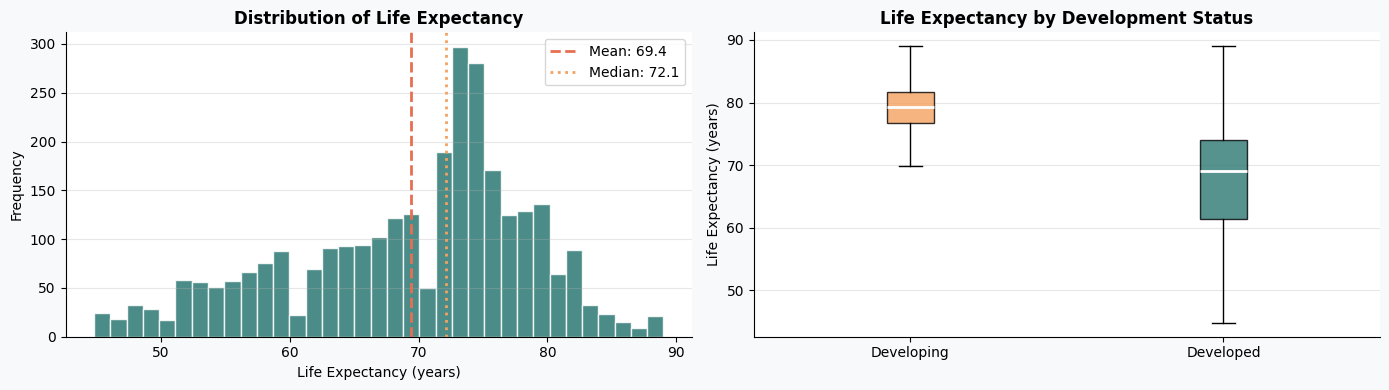

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor('#F8F9FA') # Set overall figure background

axes[0].hist(y, bins=35, color=TEAL, edgecolor='white', alpha=0.85)
axes[0].axvline(y.mean(),   color=ROSE, lw=2, ls='--', label=f'Mean: {y.mean():.1f}')
axes[0].axvline(y.median(), color=GOLD, lw=2, ls=':',  label=f'Median: {y.median():.1f}')
axes[0].set_title('Distribution of Life Expectancy', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Life Expectancy (years)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Boxplot by status
grp = df.copy()
grp['Status_Label'] = grp['Status'].map({0:'Developing', 1:'Developed'})
boxes = [grp[grp['Status_Label']==s][TARGET].values for s in ['Developing','Developed']]
bp = axes[1].boxplot(boxes, labels=['Developing','Developed'],
                     patch_artist=True, medianprops=dict(color='white', lw=2))
for patch, color in zip(bp['boxes'], [GOLD, TEAL]):
    patch.set_facecolor(color); patch.set_alpha(0.8)
axes[1].set_title('Life Expectancy by Development Status', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Life Expectancy (years)')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

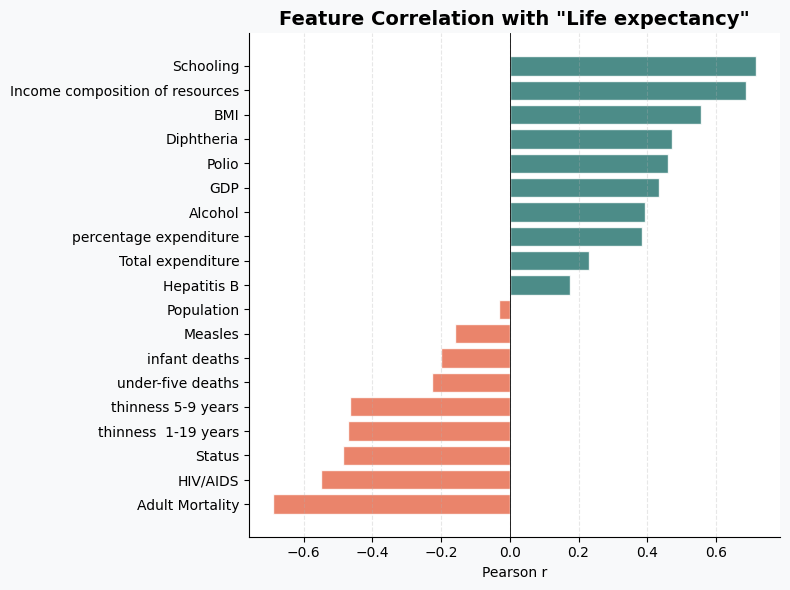

In [42]:
# Feature correlations with Target
corr = df.corr()[[TARGET]].drop(TARGET).sort_values(TARGET)
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F8F9FA')
colors_bar = [ROSE if v < 0 else TEAL for v in corr[TARGET]]
ax.barh(corr.index, corr[TARGET], color=colors_bar, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', lw=0.6)
ax.set_title(f'Feature Correlation with "{TARGET}"', fontweight='bold', fontsize=14)
ax.set_xlabel('Pearson r')  # r = +1; r = -1; r = +/-0.5 - threshold
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

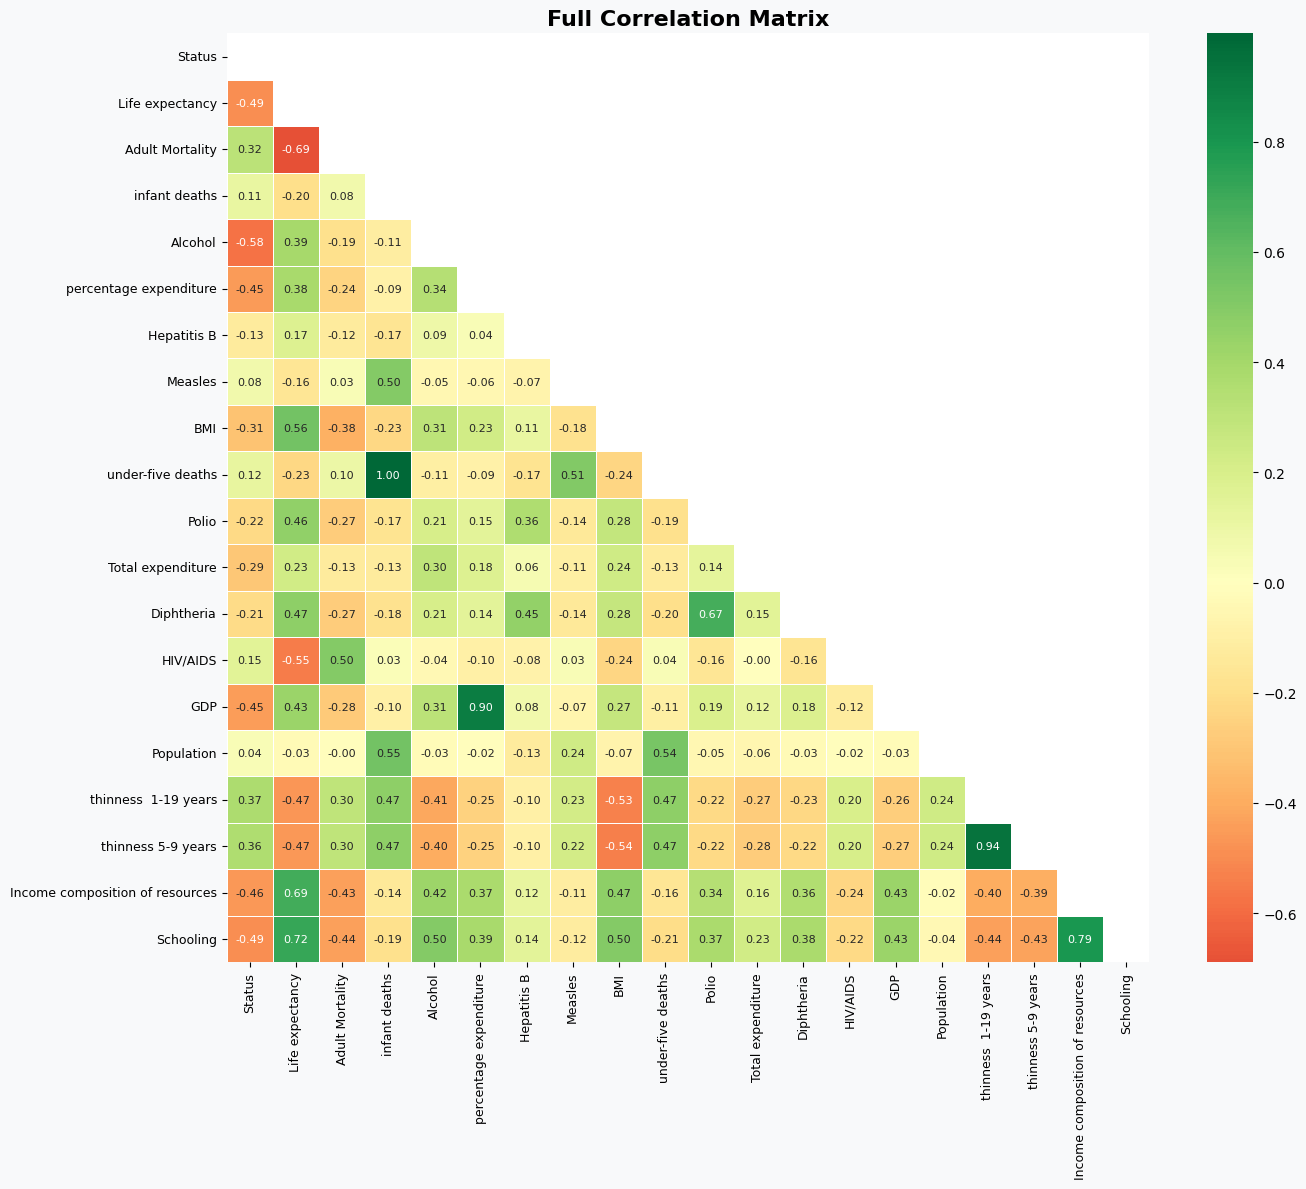

In [43]:
# Full correlation heatmap
fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor('#F8F9FA')
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), mask=mask, ax=ax, cmap='RdYlGn', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 8}, linewidths=0.5, linecolor='white')
ax.set_title('Full Correlation Matrix', fontweight='bold', fontsize=16)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout(); plt.show()

## 4. Feature Selection

Three complementary methods are applied:
- **ANOVA F-score** (`SelectKBest` with `f_regression`)
- **Random Forest Feature Importance** (200 estimators)
- **Recursive Feature Elimination (RFE)** with RF base estimator

The top 10 features ranked by RF importance are used for model training.

In [27]:
# ANOVA F-test
selector_anova = SelectKBest(score_func=f_regression, k='all')
selector_anova.fit(X_scaled_df, y)
anova_scores = pd.Series(selector_anova.scores_, index=feature_names).sort_values(ascending=False)
print("ANOVA F-scores (Top 10):")
print(anova_scores.head(10).to_string())

ANOVA F-scores (Top 10):
Schooling                          3073.544898
Adult Mortality                    2638.961465
Income composition of resources    2617.120996
BMI                                1313.826692
HIV/AIDS                           1257.556530
Status                              899.468947
Diphtheria                          838.788976
thinness  1-19 years                829.565269
thinness 5-9 years                  805.403394
Polio                               781.054246


In [28]:
# Random Forest Feature Importance
# n_estimators - hyperparameter that controls how many decision trees are built
rf_fi = RandomForestRegressor(n_estimators=200, random_state=0)
rf_fi.fit(X_train, y_train)
fi_scores = pd.Series(rf_fi.feature_importances_, index=feature_names).sort_values(ascending=False)
print("RF Feature Importances (Top 10):")
print(fi_scores.head(10).to_string())

RF Feature Importances (Top 10):
HIV/AIDS                           0.590491
Income composition of resources    0.181924
Adult Mortality                    0.127161
BMI                                0.015160
Schooling                          0.012891
under-five deaths                  0.011701
thinness 5-9 years                 0.009347
Alcohol                            0.007480
Polio                              0.005952
thinness  1-19 years               0.005888


In [29]:
# Recursive Feature Elimination (RFE)
# Recursively removes the least important features until the desired number remains
rf_base = RandomForestRegressor(n_estimators=100, random_state=0)
rfe = RFE(estimator=rf_base, n_features_to_select=10, step=1)
rfe.fit(X_scaled_df, y)
rfe_support = pd.Series(rfe.support_, index=feature_names)
rfe_ranking = pd.Series(rfe.ranking_, index=feature_names).sort_values()
print("RFE Selected Features:")
print(rfe_support[rfe_support].index.tolist())  # extracts names of selected features

RFE Selected Features:
['Adult Mortality', 'Alcohol', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'HIV/AIDS', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [30]:
rfe_support

,0
Status,False
Adult Mortality,True
infant deaths,False
Alcohol,True
percentage expenditure,False
Hepatitis B,False
Measles,False
BMI,True
under-five deaths,True
Polio,True


In [31]:
rfe_ranking

,0
Adult Mortality,1
Alcohol,1
BMI,1
under-five deaths,1
HIV/AIDS,1
Total expenditure,1
Polio,1
thinness 5-9 years,1
Income composition of resources,1
Schooling,1


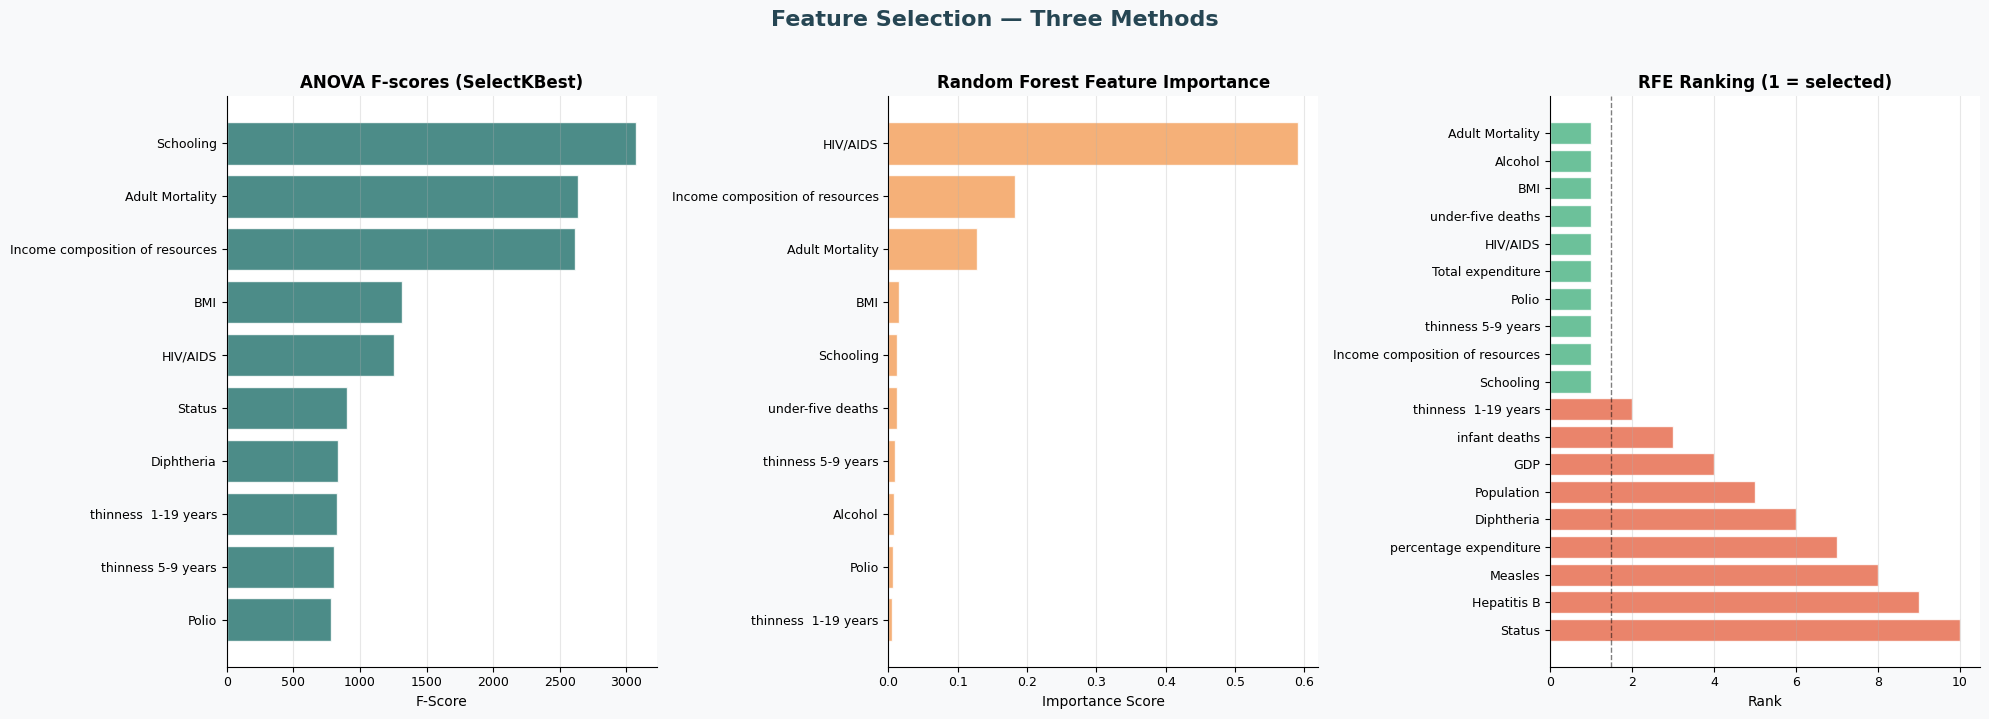


✅ Final selected features (10):
['HIV/AIDS', 'Income composition of resources', 'Adult Mortality', 'BMI', 'Schooling', 'under-five deaths', 'thinness 5-9 years', 'Alcohol', 'Polio', 'thinness  1-19 years']


In [44]:
# Visualise all three feature selection methods
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('#F8F9FA')

top_anova = anova_scores.head(10)
axes[0].barh(top_anova.index[::-1], top_anova.values[::-1], color=TEAL, edgecolor='white', alpha=0.85)
axes[0].set_title('ANOVA F-scores (SelectKBest)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('F-Score')
axes[0].grid(axis='x', alpha=0.3)

top_fi = fi_scores.head(10)
axes[1].barh(top_fi.index[::-1], top_fi.values[::-1], color=GOLD, edgecolor='white', alpha=0.85)
axes[1].set_title('Random Forest Feature Importance', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Importance Score')
axes[1].grid(axis='x', alpha=0.3)

rfe_plot = rfe_ranking.sort_values()
axes[2].barh(rfe_plot.index[::-1], rfe_plot.values[::-1],
             color=[MINT if r==1 else ROSE for r in rfe_plot.values[::-1]],
             edgecolor='white', alpha=0.85)
axes[2].set_title('RFE Ranking (1 = selected)', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Rank')
axes[2].axvline(1.5, color='black', lw=1, ls='--', alpha=0.5)
axes[2].grid(axis='x', alpha=0.3)

for ax in axes:
    ax.tick_params(axis='y', labelsize=9)
    ax.tick_params(axis='x', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Feature Selection — Three Methods', fontsize=16, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout(); plt.show()

selected_features = fi_scores.head(10).index.tolist()
print(f"\n✅ Final selected features ({len(selected_features)}):")
print(selected_features)

In [33]:
selected_features

['HIV/AIDS',
 'Income composition of resources',
 'Adult Mortality',
 'BMI',
 'Schooling',
 'under-five deaths',
 'thinness 5-9 years',
 'Alcohol',
 'Polio',
 'thinness  1-19 years']

## 5. Model Training & Evaluation

In [34]:
X_sel = X_scaled_df[selected_features]
X_tr, X_te, y_tr, y_te = train_test_split(X_sel, y, test_size=0.2, random_state=42)

regressors = [
    ('Linear Regression',  LinearRegression()),
    ('Random Forest',      RandomForestRegressor(random_state=0)),
    ('Decision Tree',      DecisionTreeRegressor(random_state=0)),
    ('SVR',                SVR()),
    ('Bagging',            BaggingRegressor(random_state=0)),
    ('Gradient Boosting',  GradientBoostingRegressor(random_state=0)),
    ('AdaBoost',           AdaBoostRegressor(random_state=0)),
    ('Ridge',              Ridge()),
    ('Lasso',              Lasso()),
    ('ElasticNet',         ElasticNet()),
    ('KNN',                KNeighborsRegressor()),
]

results = []
# R² - Coefficient of Determination; CV R² - average R² across multiple train-test splits
print(f"{'Model':<25} {'R²':>7} {'RMSE':>8} {'MAE':>8} {'CV R²':>10} {'CV Std':>8}")
print("─" * 70)

for name, model in regressors:
    model.fit(X_tr, y_tr)              # Training Phase
    y_pred = model.predict(X_te)       # Testing Phase
    cv_scores = cross_val_score(model, X_sel, y, cv=5, scoring='r2')

    r2   = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    cv_r2  = cv_scores.mean()
    cv_std = cv_scores.std()

    results.append({'Model': name, 'R2': round(r2,4), 'RMSE': round(rmse,4),
                    'MAE': round(mae,4), 'CV_R2': round(cv_r2,4),
                    'CV_Std': round(cv_std,4), 'y_pred': y_pred})
    print(f"{name:<25} {r2:>7.4f} {rmse:>8.4f} {mae:>8.4f} {cv_r2:>10.4f} {cv_std:>8.4f}")

results_df = pd.DataFrame([{k:v for k,v in r.items() if k!='y_pred'} for r in results])
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
print(f"\n Best model: {results_df.iloc[0]['Model']} (R² = {results_df.iloc[0]['R2']})")

Model                          R²     RMSE      MAE      CV R²   CV Std
──────────────────────────────────────────────────────────────────────
Linear Regression          0.7864   4.3046   3.1377     0.7564   0.0495
Random Forest              0.9652   1.7378   1.0745     0.9092   0.0206
Decision Tree              0.9306   2.4545   1.3897     0.8349   0.0232
SVR                        0.8954   3.0124   1.9877     0.8496   0.0226
Bagging                    0.9599   1.8655   1.1442     0.9000   0.0234
Gradient Boosting          0.9503   2.0756   1.5010     0.9058   0.0227
AdaBoost                   0.9045   2.8780   2.3288     0.8541   0.0194
Ridge                      0.7864   4.3046   3.1377     0.7565   0.0495
Lasso                      0.7528   4.6308   3.3459     0.7520   0.0096
ElasticNet                 0.7476   4.6791   3.4700     0.7427   0.0136
KNN                        0.9289   2.4844   1.6486     0.8373   0.0319

 Best model: Random Forest (R² = 0.9652)


## 6. Model Comparison Visualizations

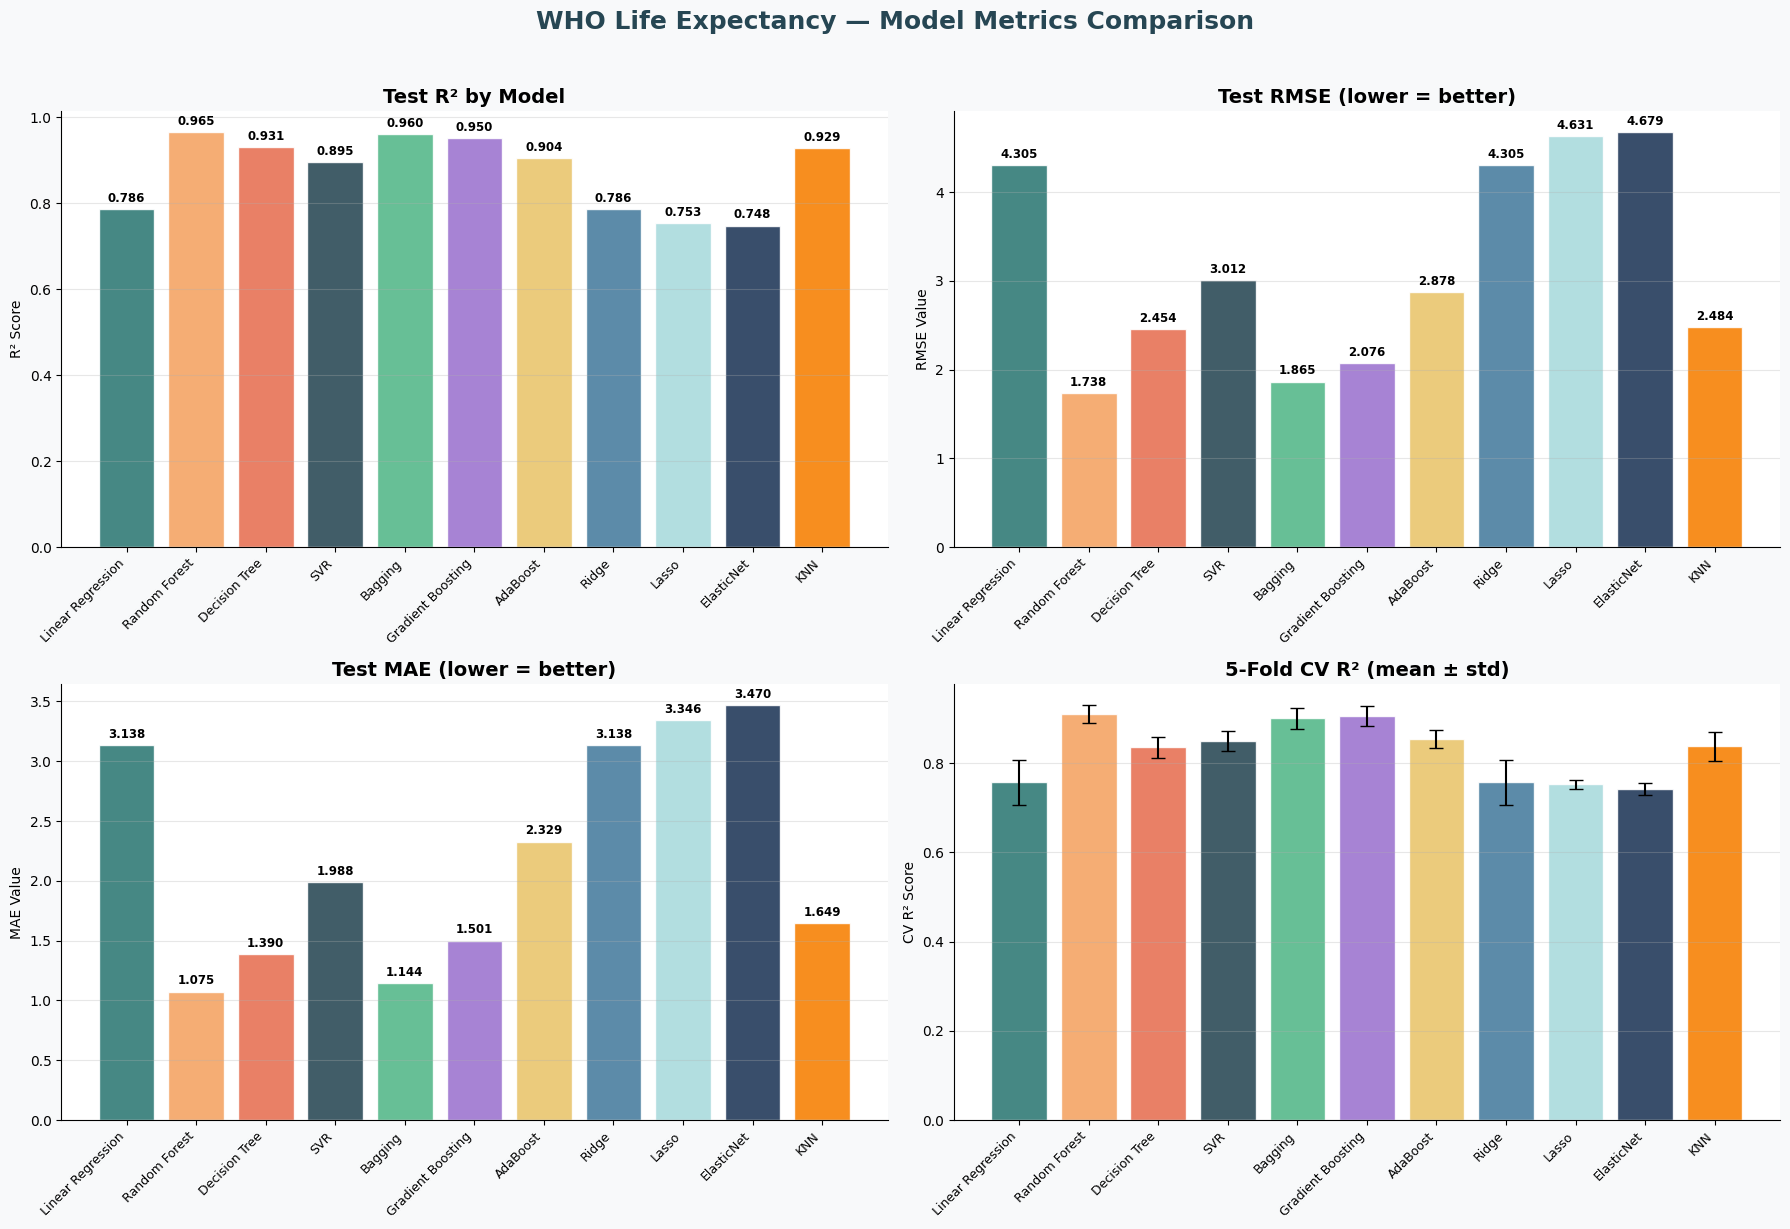

In [45]:
model_names = [r['Model'] for r in results]
r2_vals    = [r['R2']     for r in results]
rmse_vals  = [r['RMSE']   for r in results]
mae_vals   = [r['MAE']    for r in results]
cv_means   = [r['CV_R2']  for r in results]
cv_stds    = [r['CV_Std'] for r in results]

bar_colors = [COLORS[i % len(COLORS)] for i in range(len(model_names))]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor('#F8F9FA')

def bar_chart(ax, vals, title, ylabel):
    bars = ax.bar(model_names, vals, color=bar_colors, edgecolor='white', alpha=0.88)
    ax.set_title(title, fontweight='bold', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, val + max(vals)*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

bar_chart(axes[0,0], r2_vals,   'Test R² by Model',          'R² Score')
bar_chart(axes[0,1], rmse_vals, 'Test RMSE (lower = better)', 'RMSE Value')
bar_chart(axes[1,0], mae_vals,  'Test MAE (lower = better)',  'MAE Value')

axes[1,1].bar(model_names, cv_means, yerr=cv_stds, color=bar_colors, edgecolor='white',
              alpha=0.88, capsize=5, error_kw={'lw':1.5,'color':'gray'})
axes[1,1].set_title('5-Fold CV R² (mean ± std)', fontweight='bold', fontsize=14)
axes[1,1].set_ylabel('CV R² Score', fontsize=10)
axes[1,1].set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
axes[1,1].grid(axis='y', alpha=0.3)
axes[1,1].spines['top'].set_visible(False); axes[1,1].spines['right'].set_visible(False)

plt.suptitle('WHO Life Expectancy — Model Metrics Comparison', fontsize=18, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout(); plt.show()

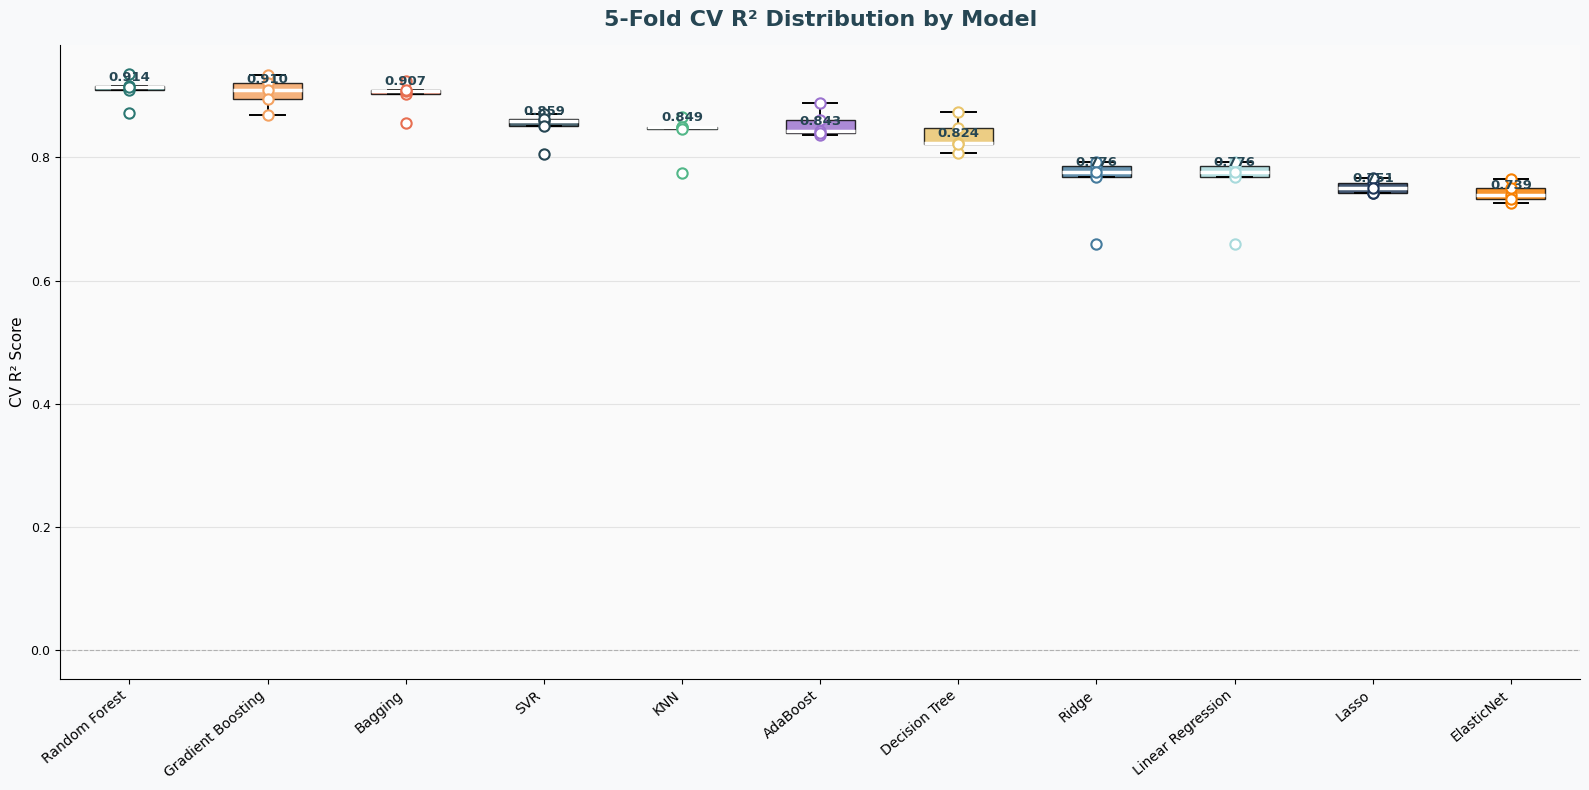

Models ranked by median CV R² (descending):
  Random Forest             median=0.9143  std=0.0206
  Gradient Boosting         median=0.9103  std=0.0227
  Bagging                   median=0.9071  std=0.0234
  SVR                       median=0.8591  std=0.0226
  KNN                       median=0.8487  std=0.0319
  AdaBoost                  median=0.8434  std=0.0194
  Decision Tree             median=0.8238  std=0.0232
  Ridge                     median=0.7764  std=0.0495
  Linear Regression         median=0.7763  std=0.0495
  Lasso                     median=0.7507  std=0.0096
  ElasticNet                median=0.7386  std=0.0136


In [46]:
# 5-Fold CV R² Boxplot — all models
cv_fold_scores = {}
for name, model in regressors:
    scores = cross_val_score(model, X_sel, y, cv=5, scoring='r2')
    cv_fold_scores[name] = scores

# Sort by median CV R²
order    = sorted(cv_fold_scores.keys(), key=lambda k: np.median(cv_fold_scores[k]), reverse=True)
data_ord = [cv_fold_scores[k] for k in order]
col_ord  = [COLORS[i % len(COLORS)] for i in range(len(order))]

fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('#F8F9FA')

bp = ax.boxplot(data_ord, labels=order, patch_artist=True,
                medianprops=dict(color='white', linewidth=2.5),
                whiskerprops=dict(linewidth=1.4),
                capprops=dict(linewidth=1.4),
                flierprops=dict(marker='o', markersize=5, alpha=0.5))
for patch, color in zip(bp['boxes'], col_ord):
    patch.set_facecolor(color); patch.set_alpha(0.82)

# Overlay individual fold scores as dots
for i, (d, color) in enumerate(zip(data_ord, col_ord)):
    ax.scatter([i+1]*len(d), d, color='white', s=55, zorder=3,
               edgecolors=color, linewidth=1.5)
    ax.text(i+1, np.median(d) + 0.005, f'{np.median(d):.3f}',
            ha='center', va='bottom', fontsize=9.5, fontweight='bold', color=NAVY)

ax.set_title('5-Fold CV R² Distribution by Model', fontweight='bold', fontsize=16, color=NAVY, pad=14)
ax.set_ylabel('CV R² Score', fontsize=11)
ax.set_xticklabels(order, rotation=40, ha='right', fontsize=10)
ax.tick_params(axis='y', labelsize=9)
ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.set_facecolor('#FAFAFA')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Models ranked by median CV R² (descending):")
for name in order:
    scores = cv_fold_scores[name]
    print(f"  {name:<25} median={np.median(scores):.4f}  std={np.std(scores):.4f}")

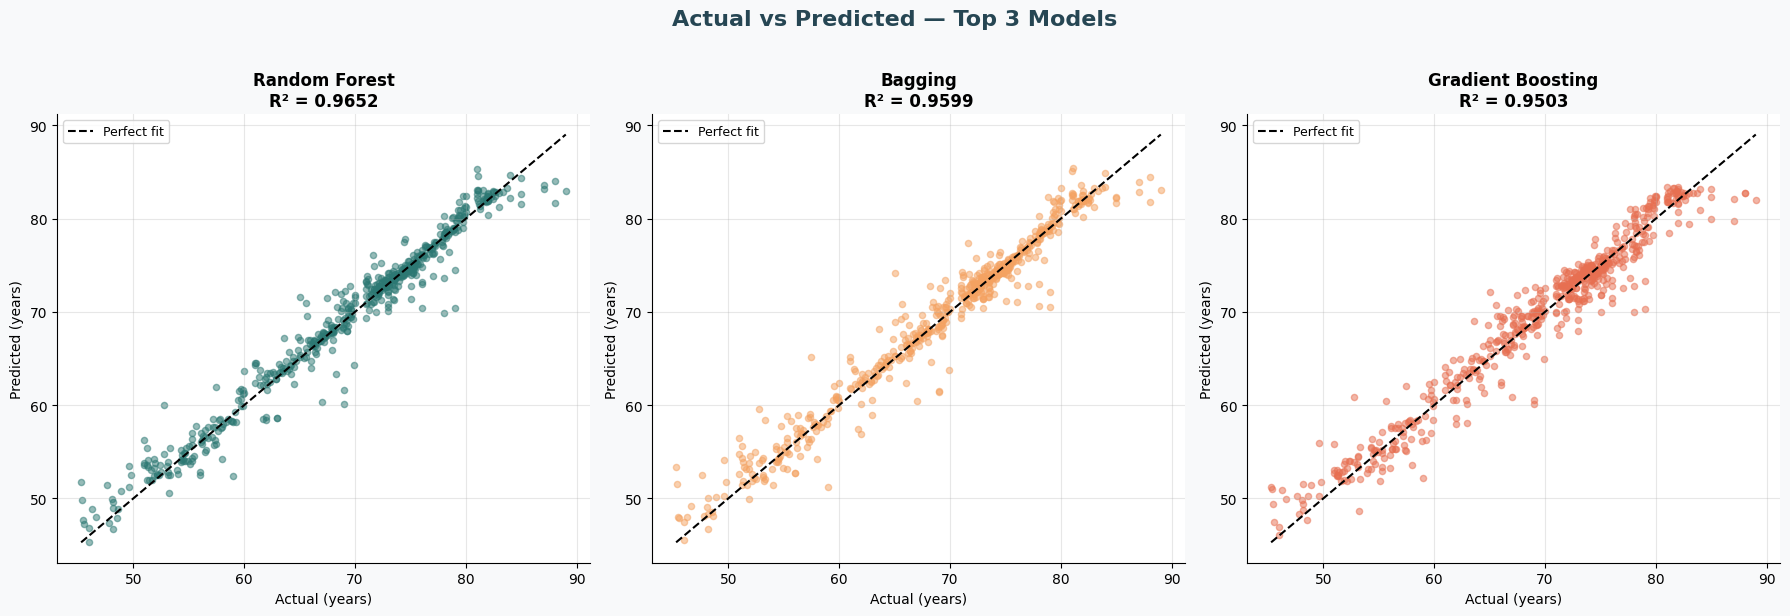

In [47]:
# Actual vs Predicted — top 3 models
top3 = results_df.head(3)['Model'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#F8F9FA')

for ax, name, color in zip(axes, top3, COLORS):
    yp = next(r['y_pred'] for r in results if r['Model']==name)
    ax.scatter(y_te, yp, alpha=0.5, color=color, s=20)
    mn, mx = min(y_te.min(), yp.min()), max(y_te.max(), yp.max())
    ax.plot([mn,mx],[mn,mx],'k--',lw=1.5,label='Perfect fit')
    r2 = r2_score(y_te, yp)
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Actual (years)', fontsize=10)
    ax.set_ylabel('Predicted (years)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('Actual vs Predicted — Top 3 Models', fontsize=16, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout(); plt.show()

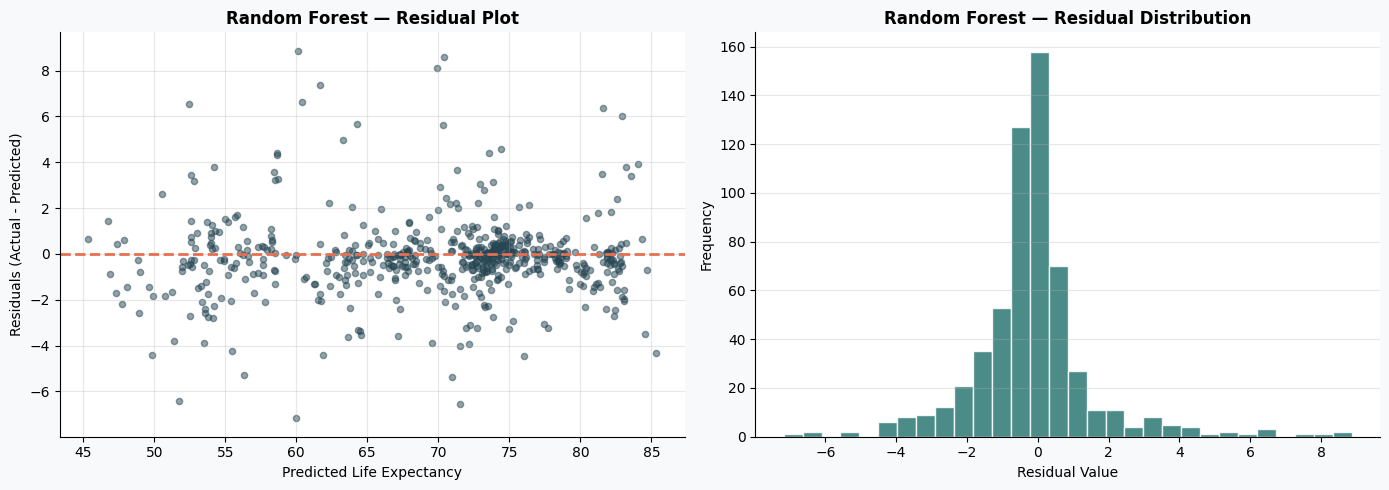

In [48]:
# Residual plot — best model
# A residual plot is a diagnostic scatter plot used to evaluate accuracy and error patterns
best_name = results_df.iloc[0]['Model']
best_pred = next(r['y_pred'] for r in results if r['Model']==best_name)
residuals = np.array(y_te) - best_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#F8F9FA')

axes[0].scatter(best_pred, residuals, alpha=0.5, color=NAVY, s=20)
axes[0].axhline(0, color=ROSE, lw=2, ls='--')
axes[0].set_title(f'{best_name} — Residual Plot', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Predicted Life Expectancy', fontsize=10)
axes[0].set_ylabel('Residuals (Actual - Predicted)', fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

axes[1].hist(residuals, bins=30, color=TEAL, edgecolor='white', alpha=0.85)
axes[1].set_title(f'{best_name} — Residual Distribution', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Residual Value', fontsize=10)
axes[1].set_ylabel('Frequency', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout(); plt.show()

## 7. Final Results Summary

In [39]:
summary = results_df[['Model','R2','RMSE','MAE','CV_R2','CV_Std']].copy()
summary.columns = ['Model', 'R²', 'RMSE', 'MAE', 'CV R² (mean)', 'CV R² (std)']
summary.index = range(1, len(summary)+1)

def highlight_best(s):
    if s.name == 'R²' or s.name == 'CV R² (mean)':
        best = s.max()
        return ['background-color: #D4EDDA; font-weight: bold' if v == best else '' for v in s]
    elif s.name in ['RMSE','MAE']:
        best = s.min()
        return ['background-color: #D4EDDA; font-weight: bold' if v == best else '' for v in s]
    return ['' for _ in s]

summary.style.apply(highlight_best, subset=['R²','RMSE','MAE','CV R² (mean)'])

,Model,R²,RMSE,MAE,CV R² (mean),CV R² (std)
1,Random Forest,0.965200,1.737800,1.074500,0.909200,0.020600
2,Bagging,0.959900,1.865500,1.144200,0.900000,0.023400
3,Gradient Boosting,0.950300,2.075600,1.501000,0.905800,0.022700
4,Decision Tree,0.930600,2.454500,1.389700,0.834900,0.023200
5,KNN,0.928900,2.484400,1.648600,0.837300,0.031900
6,AdaBoost,0.904500,2.878000,2.328800,0.854100,0.019400
7,SVR,0.895400,3.012400,1.987700,0.849600,0.022600
8,Linear Regression,0.786400,4.304600,3.137700,0.756400,0.049500
9,Ridge,0.786400,4.304600,3.137700,0.756500,0.049500
10,Lasso,0.752800,4.630800,3.345900,0.752000,0.009600


In [40]:
print("=" * 65)
print("  MODEL COMPARISON — FINAL RANKINGS")
print("=" * 65)
print(f"{'Rank':<5} {'Model':<25} {'R²':>7} {'RMSE':>8} {'MAE':>8} {'CV R²':>8}")
print("─" * 65)

for i, row in results_df.iterrows():
    medal = ['🥇','🥈','🥉'][i] if i < 3 else f'  {i+1}.'
    print(f"{medal:<5} {row['Model']:<25} {row['R2']:>7.4f} {row['RMSE']:>8.4f} {row['MAE']:>8.4f} {row['CV_R2']:>8.4f}")

print("─" * 65)
print(f"\n Best overall model : {results_df.iloc[0]['Model']}")
print(f"  R²   = {results_df.iloc[0]['R2']}")
print(f"  RMSE = {results_df.iloc[0]['RMSE']}")
print(f"  MAE  = {results_df.iloc[0]['MAE']}")
print(f"  CV R²= {results_df.iloc[0]['CV_R2']}")

  MODEL COMPARISON — FINAL RANKINGS
Rank  Model                          R²     RMSE      MAE    CV R²
─────────────────────────────────────────────────────────────────
🥇     Random Forest              0.9652   1.7378   1.0745   0.9092
🥈     Bagging                    0.9599   1.8655   1.1442   0.9000
🥉     Gradient Boosting          0.9503   2.0756   1.5010   0.9058
  4.  Decision Tree              0.9306   2.4545   1.3897   0.8349
  5.  KNN                        0.9289   2.4844   1.6486   0.8373
  6.  AdaBoost                   0.9045   2.8780   2.3288   0.8541
  7.  SVR                        0.8954   3.0124   1.9877   0.8496
  8.  Linear Regression          0.7864   4.3046   3.1377   0.7564
  9.  Ridge                      0.7864   4.3046   3.1377   0.7565
  10. Lasso                      0.7528   4.6308   3.3459   0.7520
  11. ElasticNet                 0.7476   4.6791   3.4700   0.7427
─────────────────────────────────────────────────────────────────

 Best overall model : Rando

#Prepared By:
####**CLARENCE JAY M. FETALINO**
####BSECE 4-4